In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from astropy.io import fits
from astropy.table import Table
from scipy.optimize import fsolve
import logging

logging.getLogger("matplotlib").setLevel(logging.ERROR)

In [2]:
astro_table = Table.read('catalog.fits', hdu=1)
df = astro_table.to_pandas()

if df['objname'].dtype == object:
    if isinstance(df['objname'].iloc[0], bytes):
        df['objname'] = df['objname'].str.decode('utf-8')
        
    df['objname'] = df['objname'].str.strip()

NGC1313 = df[df['objname'] == 'NGC1313']
NGC1313 = NGC1313[['objname', 'pgc', 'ra', 'dec', 'ra_nsa', 'dec_nsa', 'ra_ned', 'dec_ned',
                   'd25', 'v_h', 'v_cmb', 'v_source', 't_type', 'color_type', 'best_type', 
                   'Bt0_leda', 'BV_color_leda', 'B_lum', 'gi_color_nsa', 'i_lum_nsa', 'gr_color_sga', 
                   'r_lum_sga', 'BR_color_ned', 'R_lum_ned', 'BMag', 'gi_color', 'mag_flag', 'cf3_dist', 
                   'cf3_dist_error', 'zind_dist', 'zind_dist_error', 'zind_indicator', 'bestdist', 'bestdist_error', 
                   'bestdist_method', 'bestdist_source', 'dist_ned_flag']]

In [3]:
NGC1313

,objname,pgc,ra,dec,ra_nsa,dec_nsa,ra_ned,dec_ned,d25,v_h,...,cf3_dist,cf3_dist_error,zind_dist,zind_dist_error,zind_indicator,bestdist,bestdist_error,bestdist_method,bestdist_source,dist_ned_flag
3550,NGC1313,12286,49.565522,-66.497868,NaN,NaN,49.56688,-66.49825,11.066237,470.0,...,3.789611,4.777088,4.31,0.253945,b'TRGB',4.31,0.254,b'Karachentsev',1,0


In [4]:
ra = NGC1313['ra'].values
dec = NGC1313['dec'].values
print(ra, dec)

[49.5655215] [-66.4978677]


In [5]:
v_h = NGC1313['v_h'].values
v_cmb = NGC1313['v_cmb'].values
print(v_h, v_cmb)

[470.] [651.99]


In [6]:
NGC1313['bestdist'].values

array([4.31], dtype=float32)

In [7]:
cf3_dist = NGC1313['cf3_dist'].values
print(cf3_dist)

[3.7896109]


In [8]:
NGC1313_useful = NGC1313[['Bt0_leda', 'BV_color_leda', 'B_lum', 'd25']]

In [9]:
NGC1313_useful

,Bt0_leda,BV_color_leda,B_lum,d25
3550,9.175,0.395642,8.656105e+09,11.066237


# Hubble Flow Distance

In [10]:
def distance_calculator(z, zerr, H_0type):
    c = 299792
    H0_mode = H_0type.lower()
    if H0_mode == 'local':
        d_local = c*z/73
        d_localerr = zerr*(c/73)
        return d_local, d_localerr
    if H0_mode == 'cmb':
        d_CMB = c*z/68
        d_CMBerr = zerr*(c/68)
        return d_CMB, d_CMBerr
    else:
        raise ValueError("H_0type must be either 'local' or 'cmb'")

In [11]:
d_local, d_localerr = distance_calculator(z = 0.001568, zerr = 6.67e-6, H_0type = 'local')
print(d_local, d_localerr)
d_CMB, d_CMBerr = distance_calculator(z = 0.00147, zerr = 1e-05, H_0type = 'cmb')
print(d_CMB, d_CMBerr)

6.439367890410959 0.027391953972602738
6.480797647058823 0.04408705882352942


# HyperLEDA Absolute Magnitude $B$-band

In [12]:
def M_B_calculator(M_sunB, L_solarunits): #from distance modulus; given app mag and D_L
    # for M
    M_B = M_sunB - (2.5)*(np.log10(L_solarunits))
    return M_B

In [13]:
M_B = M_B_calculator(5.44, 8.656105e+9)
M_B

np.float64(-19.403306289647695)

# V-band apparent magnitude

In [14]:
def V_band_calculator(mag, color, B): #given B-V and B is given
    if mag == "abs":
        M_V = B - color
        return M_V
    if mag == "app":
        m_V = B - color
        return m_V

In [15]:
M_V = V_band_calculator(mag = "abs", color = 0.395642, B = M_B)
m_V = V_band_calculator(mag = "app", color = 0.395642, B = 9.175)
print(M_V, m_V)

-19.798948289647694 8.779358


# Luminosity in solar units

In [16]:
def L_calculator(M, M_sun): # given that the magnitudes are in the same system
    # for L
    L = 10**((-2/5)*(M - M_sun))
    return L

In [17]:
L_V = L_calculator(M_V, 4.81)
L_V

np.float64(6975563810.276908)

In [18]:
L_B = L_calculator(M_B, 5.44)
L_B

np.float64(8656105000.000046)

# Isophotal Radius

In [23]:
def isophotal_radius(D_arcmin, d_TRGB_Mpc):
    # D_arcmin -> radian
    theta = (D_arcmin * 0.000290888)/2
    R = (d_TRGB_Mpc*(10**6)) * theta
    return R

In [24]:
R25 = isophotal_radius(11.066, 4.31)
R25

6936.873040240001

# Central Surface Luminosity Density $I_0$

In [25]:
# --- I_0 solver ---
def I0_solver(M_sun, L_tot, R25_pc):
    """
    Calculates the central surface luminosity density (I0) for a specific band.
    
    Parameters:
    M_sun (float): Absolute magnitude of the Sun in the target band.
    L_tot (float): Total consistent baseline luminosity in the target band (L_sun).
    R25_pc (float): Geometrically derived physical radius in parsecs.
    """
    
    # I_25 per band, using M_sun per band
    I25 = 10**(0.4 * (M_sun - 3.428))
    
    def target_equation(I0):
        if I0 <= 0: 
            return 1e9  
            
        left_side = np.log(I0 / I25) * (np.sqrt(I0) / I0)
        right_side = R25_pc * np.sqrt((2 * np.pi) / L_tot)
        
        return left_side - right_side
    
    initial_guesses = [1, 5, 10, 50, 100, 500, 1000, 5000]
    solutions = []
    
    for guess in initial_guesses:
        solution, info, ier, message = fsolve(target_equation, x0=[guess], full_output=True) # full_output=True to check for convergence
        solution = solution[0]
        
        # Check for zero residual
        if ier == 1 and solution > 0:
            residual = abs(target_equation(solution))
            
            if residual < 1e-8:
                solutions.append(solution)
    
    unique_solutions = []
    for solution in solutions:
        if not any(np.isclose(solution, existing) for existing in unique_solutions):
            unique_solutions.append(solution)
    
    # Select the higher-I0 mathematical solution
    I0_solution = max(unique_solutions)
    
    return I0_solution, I25, unique_solutions

# --- R_d solver ---
def R50_solver(R25_pc, I25, I0):
    Rd = (R25_pc)/(np.log(I0 / I25))
    R50 = 1.678*Rd
    return R50

# --- INPUT VALUES FOR NGC 1313 ---

R25_calculated = 6937.0  # parsecs

# Known values
M_sun_V = 4.81
M_sun_B = 5.44
L_tot_V = 6.974052e9 
L_tot_B = 8.656105e9 

# --- RUNNING THE SOLVERS ---

# B-band
I0_B, I25_B, B_solutions = I0_solver(M_sun = M_sun_B, L_tot = L_tot_B, R25_pc = R25_calculated)
R50_B = R50_solver(R25_pc = R25_calculated, I25 = I25_B, I0 = I0_B)

# V-band
I0_V, I25_V, V_solutions = I0_solver(M_sun = M_sun_V, L_tot = L_tot_V, R25_pc = R25_calculated)
R50_V = R50_solver(R25_pc = R25_calculated, I25 = I25_V, I0 = I0_V)

print(f"--- NGC 1313 Profile Solutions ---")
print(f"B-band:")
print(f"  All valid solutions: {B_solutions}")
print(f"  I_0(B) : {I0_B:.4f} L_sun/pc^2")
print(f"  I_25(B): {I25_B:.4f} L_sun/pc^2")
print(f"  R_50(B): {R50_B:.4f} pc")
print(f"V-band:")
print(f"  All valid solutions: {V_solutions}")
print(f"  I_0(V) : {I0_V:.4f} L_sun/pc^2")
print(f"  I_25(V): {I25_V:.4f} L_sun/pc^2")
print(f"  R_50(V): {R50_V:.4f} pc")

--- NGC 1313 Profile Solutions ---
B-band:
  All valid solutions: [np.float64(12.28156316862912), np.float64(584.1071180406356)]
  I_0(B) : 584.1071 L_sun/pc^2
  I_25(B): 6.3797 L_sun/pc^2
  R_50(B): 2577.0155 pc
V-band:
  All valid solutions: [np.float64(5.9291237488015245), np.float64(609.214191702052)]
  I_0(V) : 609.2142 L_sun/pc^2
  I_25(V): 3.5711 L_sun/pc^2
  R_50(V): 2264.9552 pc


# $V$-band to $r$-band 

In [26]:
def V_to_r(MV, BV_color):
    M_r = MV - (0.19*(BV_color)) - 0.02
    return M_r

In [30]:
M_r = V_to_r(MV = M_V, BV_color = 0.395642)
M_r

np.float64(-19.894120269647694)

# Size-Mass relation plot

In [31]:
late = pd.read_csv("late-type-shen.csv")
early = pd.read_csv("early-type-shen.csv")

In [32]:
late_Mr = np.array(late["x"].values)
early_Mr = np.array(early["x"].values)
late_R50 = np.array(late[" y"].values)
early_R50 = np.array(early[" y"].values)

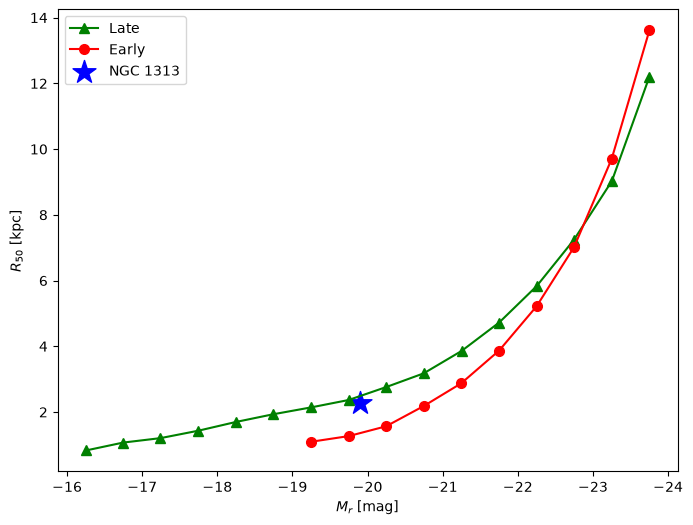

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(late_Mr,
         late_R50,
         label="Late",
         color="green",
         marker="^",
         linestyle="-",
         markersize=7)

plt.plot(early_Mr, 
         early_R50, 
         label="Early", 
         color="red", 
         marker="o", 
         linestyle="-",
         markersize = 7)

plt.scatter(x = -19.894120269647694, 
            y = 2.2649552, 
            label = "NGC 1313", 
            color = "blue", 
            marker = "*", 
            s = 300)

plt.gca().invert_xaxis()

plt.xlabel(r"$M_r$ [mag]")
plt.ylabel(r"$R_{50}$ [kpc]")
plt.legend()

plt.show()
